# PCA Implementation

In [1]:
import numpy as np
import pandas as pd

X = np.array([
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 7],
    [6, 8]
])

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

df

,Feature_1,Feature_2
0,2,3
1,3,4
2,4,5
3,5,7
4,6,8


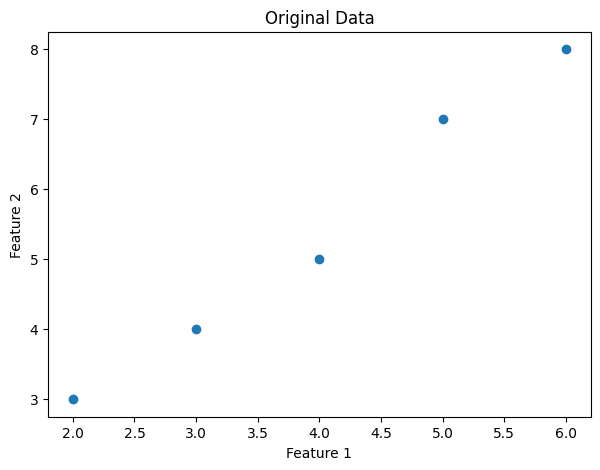

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    df["Feature_1"],
    df["Feature_2"]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data")

plt.show()

In [3]:
X_mean = X.mean(axis=0)

print("Feature means:", X_mean)

Feature means: [4.  5.4]


In [4]:
X_centered = X - X_mean

print(X_centered)

[[-2.  -2.4]
 [-1.  -1.4]
 [ 0.  -0.4]
 [ 1.   1.6]
 [ 2.   2.6]]


In [5]:
cov_matrix = np.cov(
    X_centered,
    rowvar=False
)

print(cov_matrix)

[[2.5  3.25]
 [3.25 4.3 ]]


In [6]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[0.02768625 6.77231375]

Eigenvectors:
[[-0.79588915 -0.60544237]
 [ 0.60544237 -0.79588915]]


In [7]:
order = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[order]
eigenvectors_sorted = eigenvectors[:, order]

print("Sorted eigenvalues:")
print(eigenvalues_sorted)

print("\nSorted eigenvectors:")
print(eigenvectors_sorted)

Sorted eigenvalues:
[6.77231375 0.02768625]

Sorted eigenvectors:
[[-0.60544237 -0.79588915]
 [-0.79588915  0.60544237]]


In [8]:
explained_variance_ratio = (
    eigenvalues_sorted /
    eigenvalues_sorted.sum()
)

print(explained_variance_ratio)

[0.99592849 0.00407151]


In [9]:
X_pca = X_centered @ eigenvectors_sorted

print(X_pca)

[[ 3.1210187   0.13871662]
 [ 1.71968718 -0.05173016]
 [ 0.31835566 -0.24217695]
 [-1.87886501  0.17281863]
 [-3.28019653 -0.01762815]]


In [10]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca_sklearn = pca.fit_transform(X_centered)

print(X_pca_sklearn)

[[-3.1210187  -0.13871662]
 [-1.71968718  0.05173016]
 [-0.31835566  0.24217695]
 [ 1.87886501 -0.17281863]
 [ 3.28019653  0.01762815]]


In [11]:
print("Components:")
print(pca.components_)

print("Explained variance:")
print(pca.explained_variance_)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Components:
[[ 0.60544237  0.79588915]
 [ 0.79588915 -0.60544237]]
Explained variance:
[6.77231375 0.02768625]
Explained variance ratio:
[0.99592849 0.00407151]


In [12]:
pca = PCA()
X_pca = pca.fit_transform(X)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [14]:
print("Original shape:", X.shape)
print("PCA shape:", X_pca.shape)

Original shape: (5, 2)
PCA shape: (5, 2)


In [15]:
pca_1 = PCA(n_components=1)

X_pca_1 = pca_1.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca_1.shape)

Original shape: (5, 2)
Reduced shape: (5, 1)


In [16]:
print(
    "Explained variance ratio:",
    pca_1.explained_variance_ratio_
)

Explained variance ratio: [0.99562035]


In [17]:
pca = PCA(n_components=0.95)

X_reduced = pca.fit_transform(X_scaled)

In [18]:
print("Components kept:", pca.n_components_)
print("Explained variance:",
      pca.explained_variance_ratio_.sum())

Components kept: 1
Explained variance: 0.9956203535809651


### Let's use a realistic dataset

In [19]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Original shape:", X.shape)

Original shape: (569, 30)


In [20]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (569, 30)
PCA shape: (569, 30)


In [22]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


In [23]:
print(explained_variance.sum())

1.0


In [24]:
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance)

[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]


In [25]:
variance_df = pd.DataFrame({
    "Component": range(1, len(explained_variance) + 1),
    "Explained_Variance": explained_variance,
    "Cumulative_Variance": cumulative_variance
})

variance_df.head(10)

,Component,Explained_Variance,Cumulative_Variance
0,1,0.442720,0.442720
1,2,0.189712,0.632432
2,3,0.093932,0.726364
3,4,0.066021,0.792385
4,5,0.054958,0.847343
5,6,0.040245,0.887588
6,7,0.022507,0.910095
7,8,0.015887,0.925983
8,9,0.013896,0.939879
9,10,0.011690,0.951569


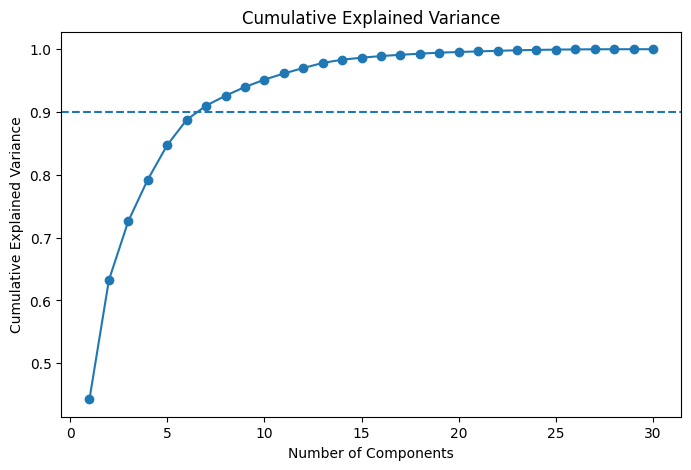

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    variance_df["Component"],
    variance_df["Cumulative_Variance"],
    marker="o"
)

plt.axhline(
    0.90,
    linestyle="--"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.show()

In [27]:
pca_95 = PCA(n_components=0.95)

X_95 = pca_95.fit_transform(X_scaled)

print("Original dimensions:", X.shape[1])
print("Reduced dimensions:", X_95.shape[1])
print(
    "Variance retained:",
    pca_95.explained_variance_ratio_.sum()
)

Original dimensions: 30
Reduced dimensions: 10
Variance retained: 0.951568814336667


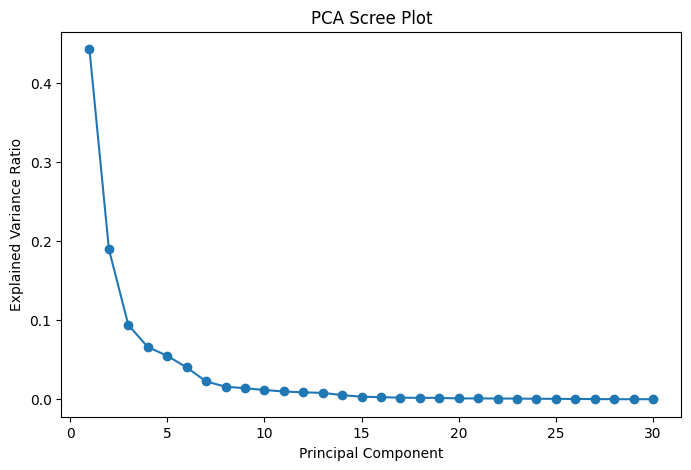

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(
    variance_df["Component"],
    variance_df["Explained_Variance"],
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")

plt.show()

In [29]:
components_95 = (
    variance_df[
        variance_df["Cumulative_Variance"] >= 0.95
    ]["Component"]
    .iloc[0]
)

print("Components needed for 95% variance:", components_95)

Components needed for 95% variance: 10


In [30]:
pca_final = PCA(n_components=10)

X_reduced = pca_final.fit_transform(X_scaled)

print(X_reduced.shape)

(569, 10)


In [31]:
pca_2 = PCA(n_components=2)

X_2d = pca_2.fit_transform(X_scaled)

print(X_2d.shape)
print(pca_2.explained_variance_ratio_)

(569, 2)
[0.44272026 0.18971182]


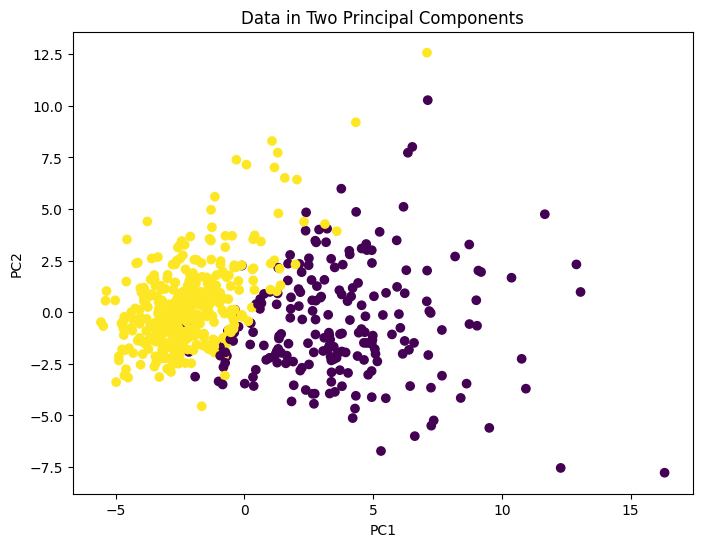

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data in Two Principal Components")

plt.show()